In [1]:
library(ggplot2)
data(diamonds)

In [2]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.2.0     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
str(diamonds)

tibble [53,940 × 10] (S3: tbl_df/tbl/data.frame)
 $ carat  : num [1:53940] 0.23 0.21 0.23 0.29 0.31 0.24 0.24 0.26 0.22 0.23 ...
 $ cut    : Ord.factor w/ 5 levels "Fair"<"Good"<..: 5 4 2 4 2 3 3 3 1 3 ...
 $ color  : Ord.factor w/ 7 levels "D"<"E"<"F"<"G"<..: 2 2 2 6 7 7 6 5 2 5 ...
 $ clarity: Ord.factor w/ 8 levels "I1"<"SI2"<"SI1"<..: 2 3 5 4 2 6 7 3 4 5 ...
 $ depth  : num [1:53940] 61.5 59.8 56.9 62.4 63.3 62.8 62.3 61.9 65.1 59.4 ...
 $ table  : num [1:53940] 55 61 65 58 58 57 57 55 61 61 ...
 $ price  : int [1:53940] 326 326 327 334 335 336 336 337 337 338 ...
 $ x      : num [1:53940] 3.95 3.89 4.05 4.2 4.34 3.94 3.95 4.07 3.87 4 ...
 $ y      : num [1:53940] 3.98 3.84 4.07 4.23 4.35 3.96 3.98 4.11 3.78 4.05 ...
 $ z      : num [1:53940] 2.43 2.31 2.31 2.63 2.75 2.48 2.47 2.53 2.49 2.39 ...


In [4]:
# verify that there aren't any missing values
max(colSums(is.na(diamonds)))

[1] 0

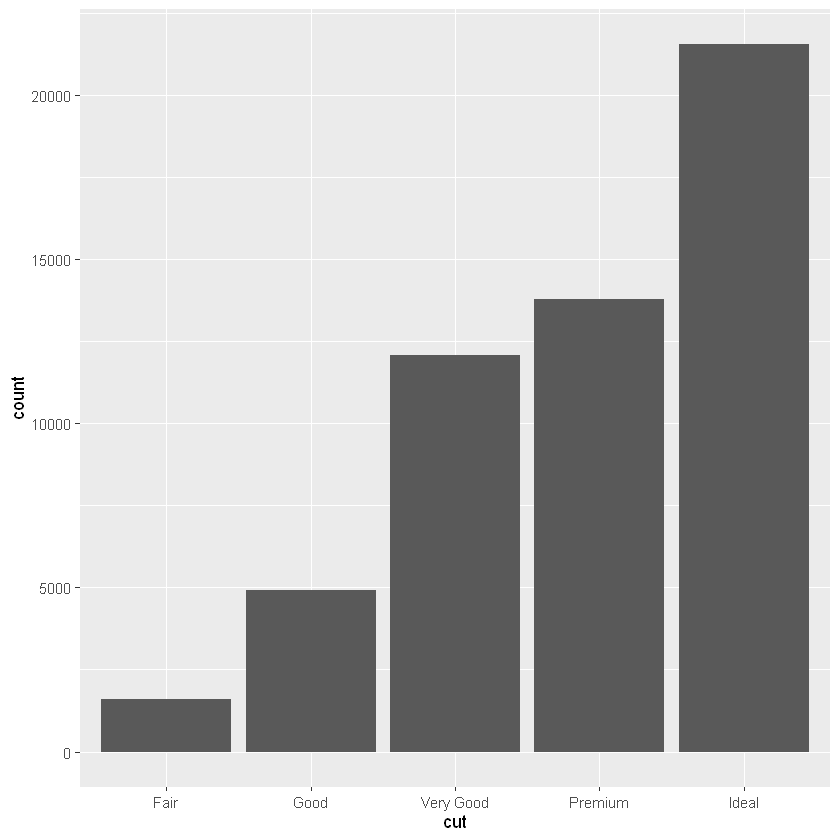

In [5]:
# Categorical variables visualization
ggplot(data = diamonds) +
    geom_bar(mapping=aes(x=cut))

In [6]:
# Compute the count in the bar graph manually
diamonds %>%
    count(cut)

cut,n
<ord>,<int>
Fair,1610
Good,4906
Very Good,12082
Premium,13791
Ideal,21551


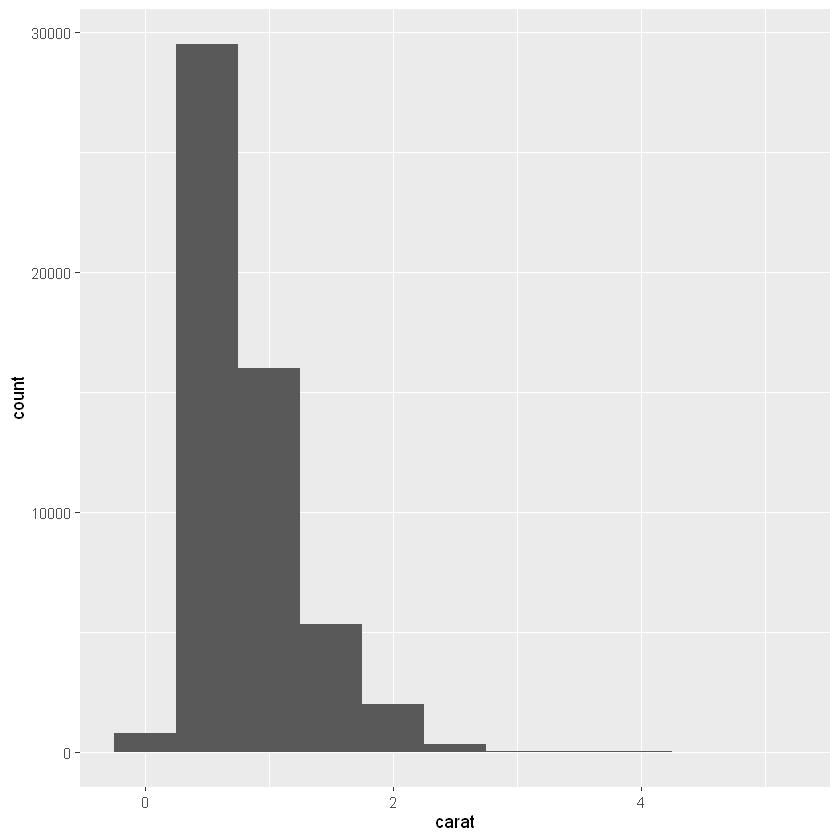

In [7]:
# Plot continuous variable with histogram
ggplot(data=diamonds) + 
    geom_histogram(mapping=aes(x=carat), binwidth=0.5)

In [8]:
diamonds %>%
    count(cut_width(carat, 0.5))

"cut_width(carat, 0.5)",n
<fct>,<int>
"[-0.25,0.25]",785
"(0.25,0.75]",29498
"(0.75,1.25]",15977
"(1.25,1.75]",5313
"(1.75,2.25]",2002
"(2.25,2.75]",322
"(2.75,3.25]",32
"(3.25,3.75]",5
"(3.75,4.25]",4


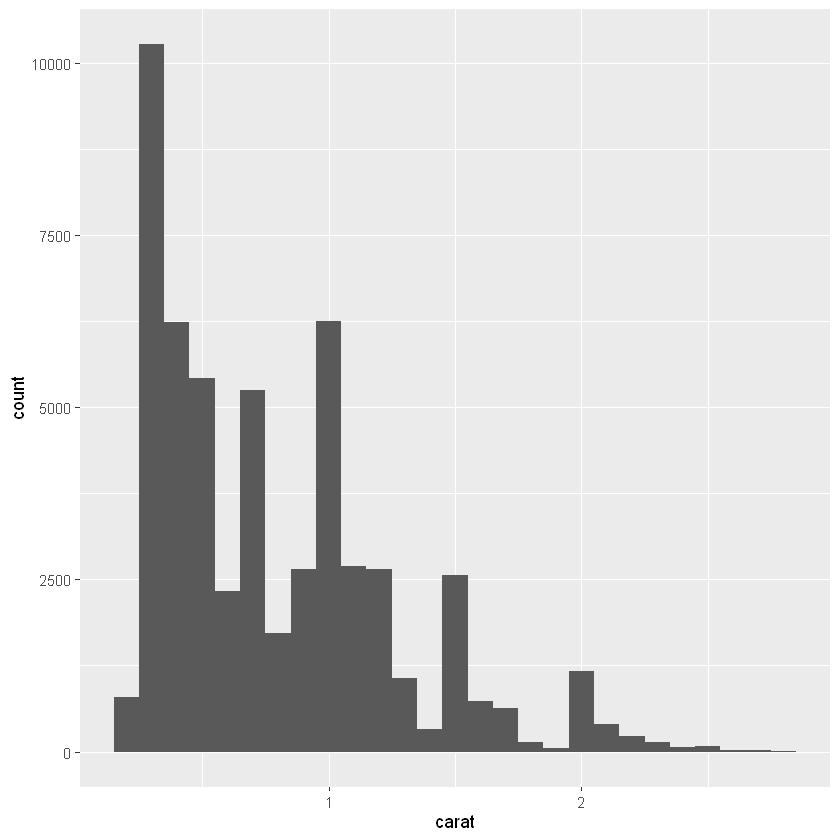

In [9]:
# Filter to smaller carats and choose a small binwidth
smaller <- diamonds %>%
    filter(carat < 3)
ggplot(data=smaller, mapping=aes(x=carat)) +
    geom_histogram(binwidth=0.1)

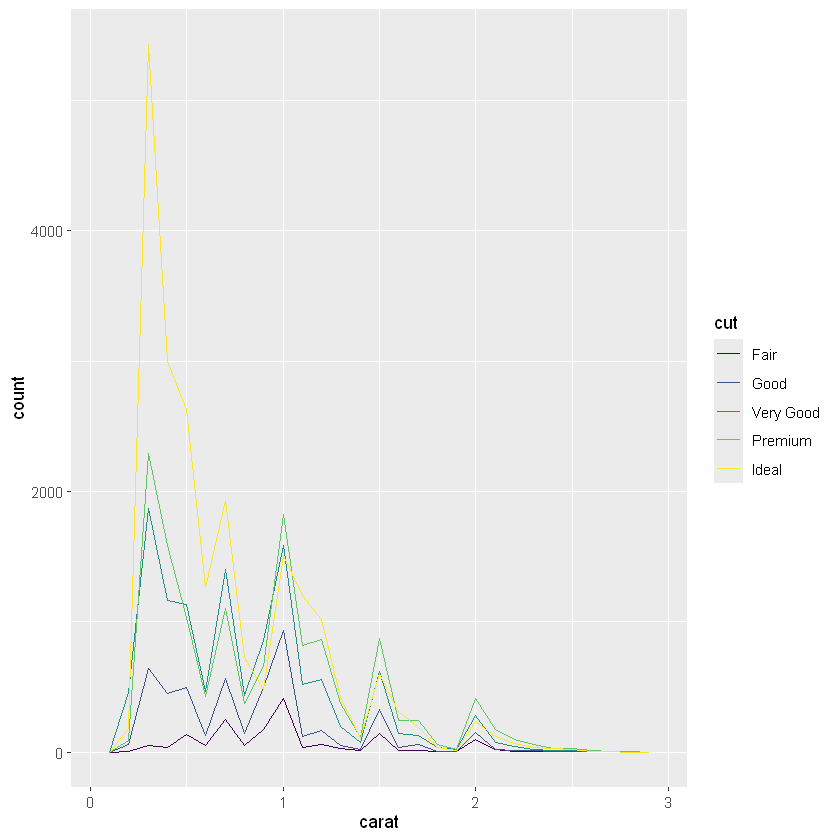

In [10]:
# Overlay multiple histograms in the same plot (uses lines instead of bars)
ggplot(data=smaller, mapping=aes(x=carat, color=cut)) +
    geom_freqpoly(binwidth=0.1)

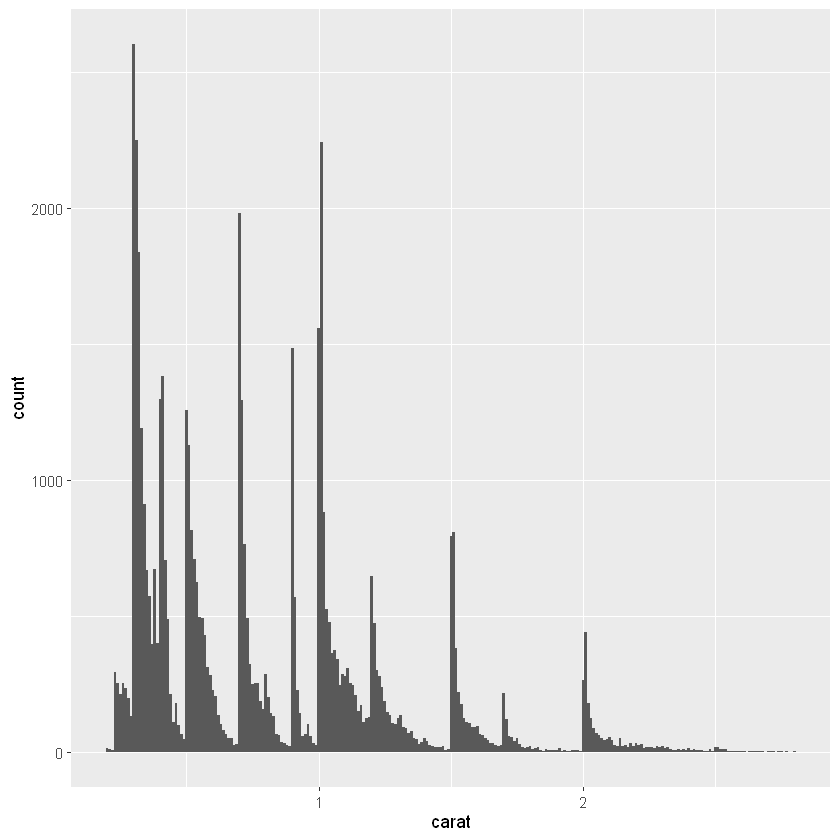

In [ ]:
# Generate histogram of carat size
ggplot(data=smaller, mapping=aes(x=carat)) +
    geom_histogram(binwidth=0.01)

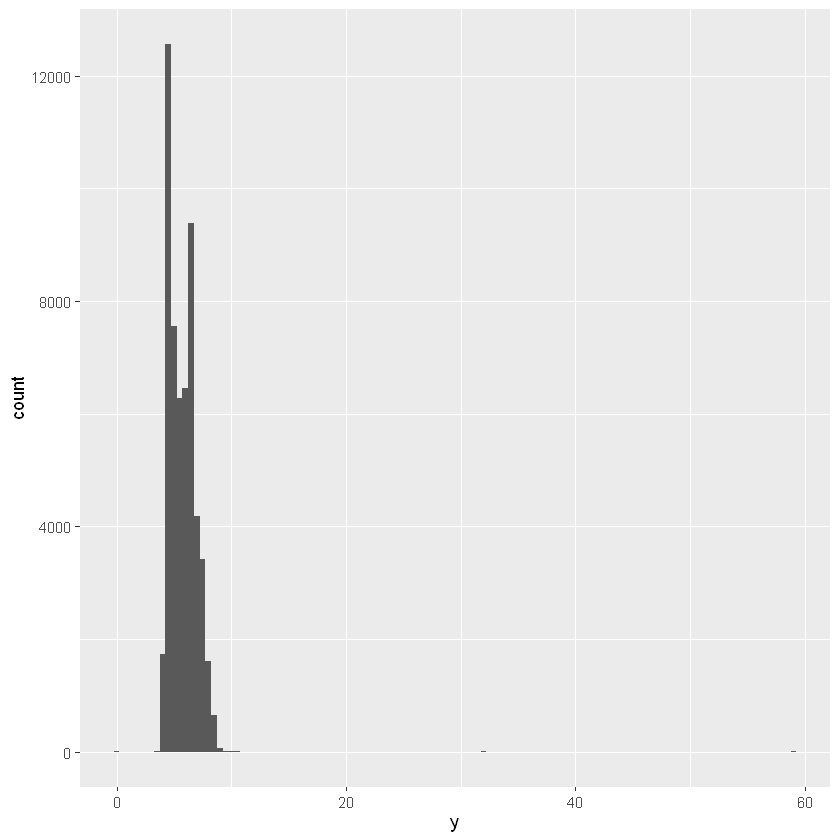

In [13]:
ggplot(diamonds) +
    geom_histogram(mapping=aes(x=y), binwidth=0.5)

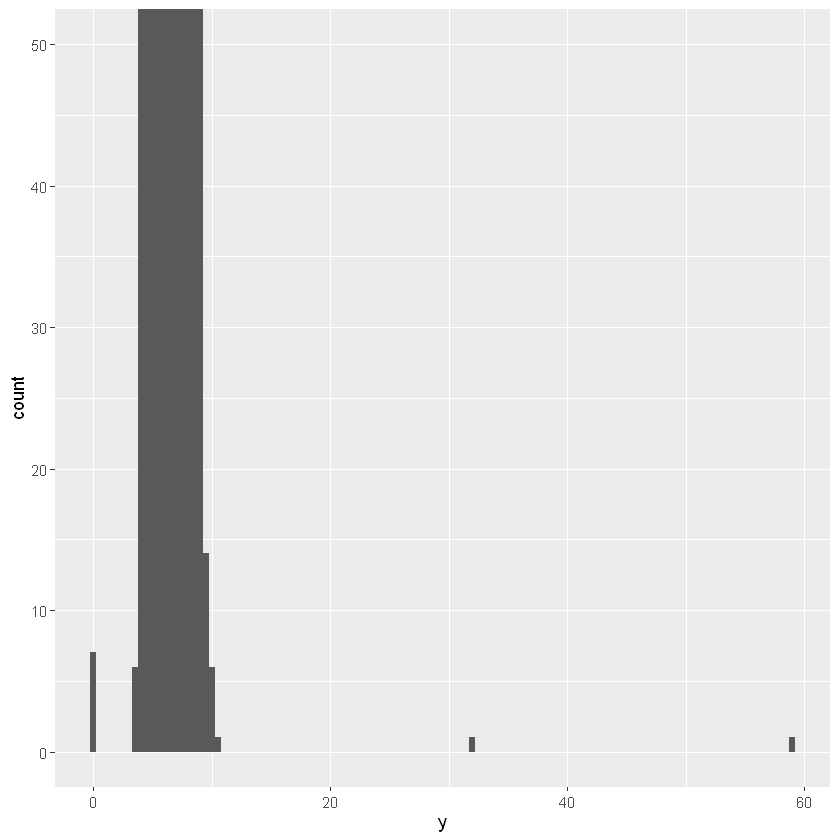

In [ ]:
# Zoom in to spot outliers
ggplot(diamonds) + 
    geom_histogram(mapping=aes(x=y), binwidth=0.5) +
    coord_cartesian(ylim=c(0, 50))

In [16]:
unusual <- diamonds %>%
    filter(y < 3 | y > 20) %>%
    select(price, x, y, z) %>%
    arrange(y)
unusual

price,x,y,z
<int>,<dbl>,<dbl>,<dbl>
5139,0.00,0.0,0.00
6381,0.00,0.0,0.00
12800,0.00,0.0,0.00
15686,0.00,0.0,0.00
18034,0.00,0.0,0.00
2130,0.00,0.0,0.00
2130,0.00,0.0,0.00
2075,5.15,31.8,5.12
12210,8.09,58.9,8.06


In [18]:
# diamonds2 <- diamonds %>%
#     filter(between(y, 3, 20)) # Not the best option
diamonds2 <- diamonds %>%
    mutate(y = ifelse(y < 3 | y > 20, NA, y))

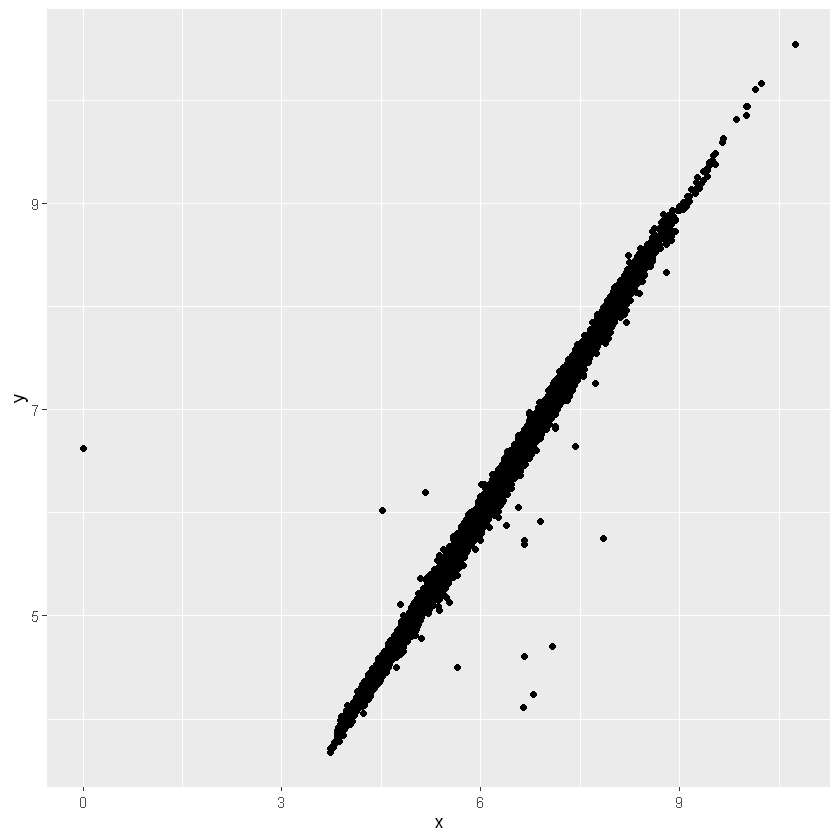

In [20]:
ggplot(data=diamonds2, mapping=aes(x=x,y=y)) +
    geom_point(na.rm=TRUE)

In [ ]:
nycflights13::flights %>%
    mutate(
        cancelled = is.na(dep_time),
        sched_hour = sched_dep_time %/% 100,
        sched_min = sched_dep_time %% 100,
        sched_dep_time = sched_hour + sched_min / 60
    ) %>%
    ggplot(mapping=aes(sched_dep_time)) +
    geom_freqpoly(
        mapping=aes(color=cancelled), binwidth=1/4)

ERROR: Error in loadNamespace(x): there is no package called 'nycflights13'


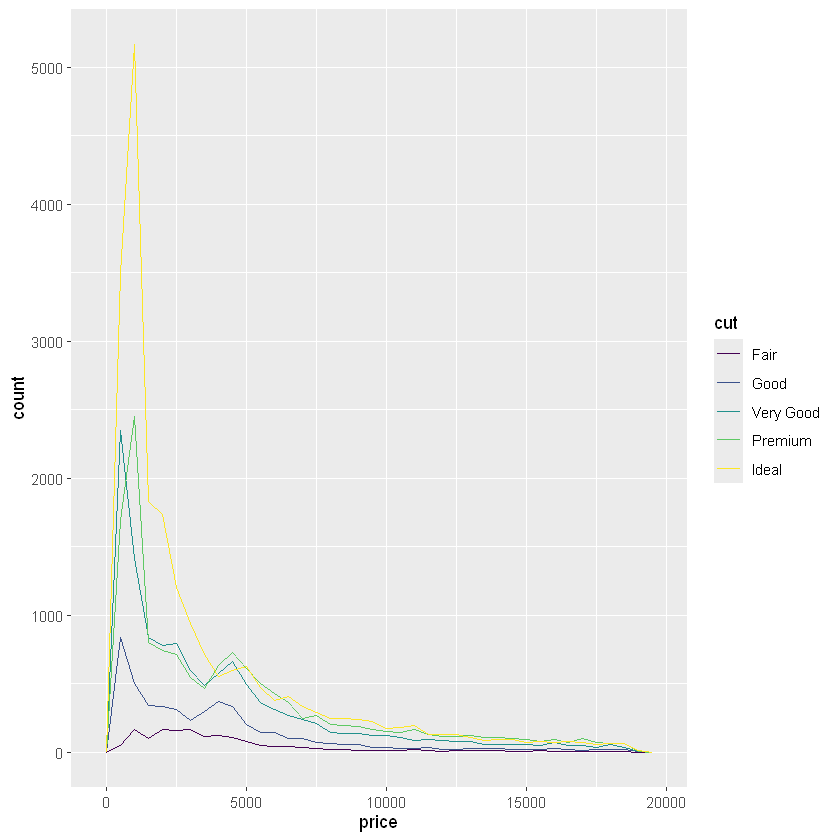

In [25]:
ggplot(data=diamonds, mapping=aes(x=price)) +
    geom_freqpoly(mapping=aes(color=cut), binwidth=500)

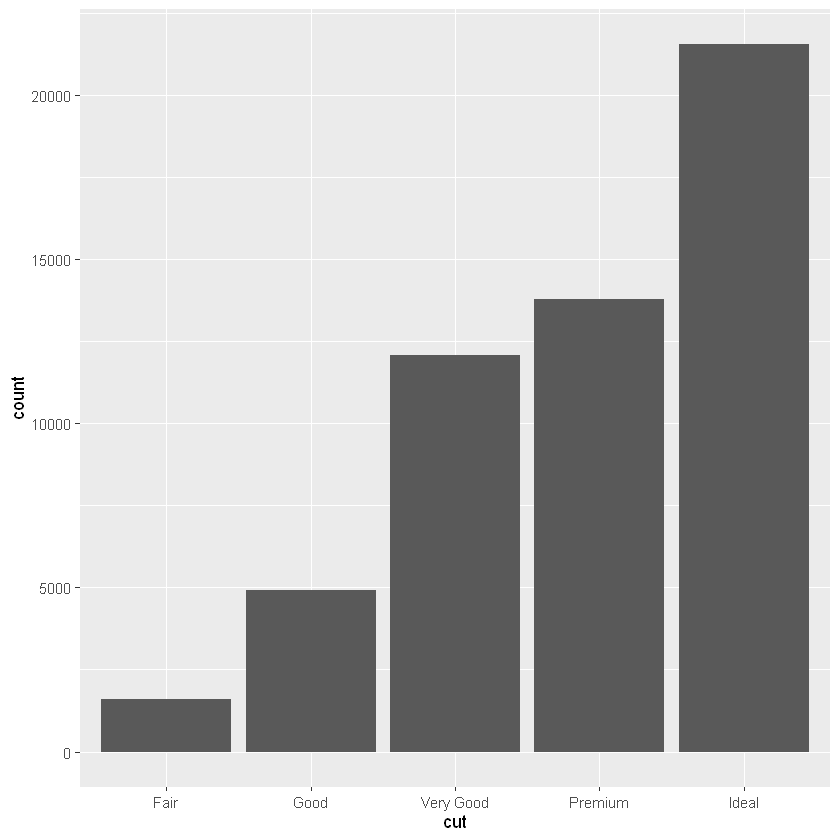

In [26]:
ggplot(diamonds) + 
    geom_bar(mapping=aes(x=cut))

Warning message:
"The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead."


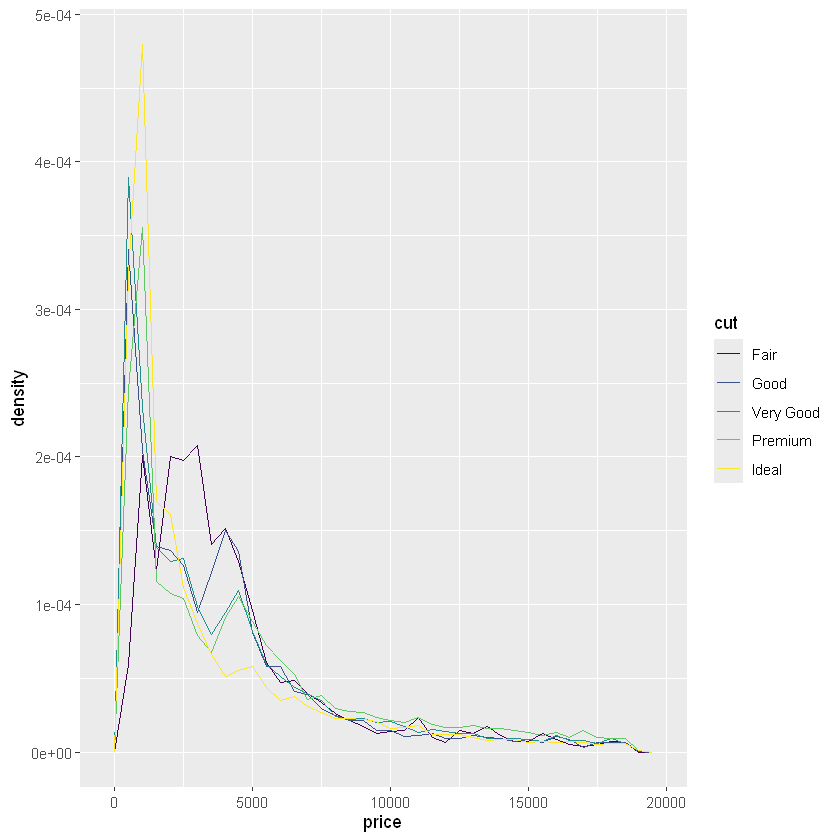

In [27]:
ggplot(data=diamonds, mapping=aes(x=price, y=..density..)) +
    geom_freqpoly(mapping=aes(color=cut), binwidth=500)

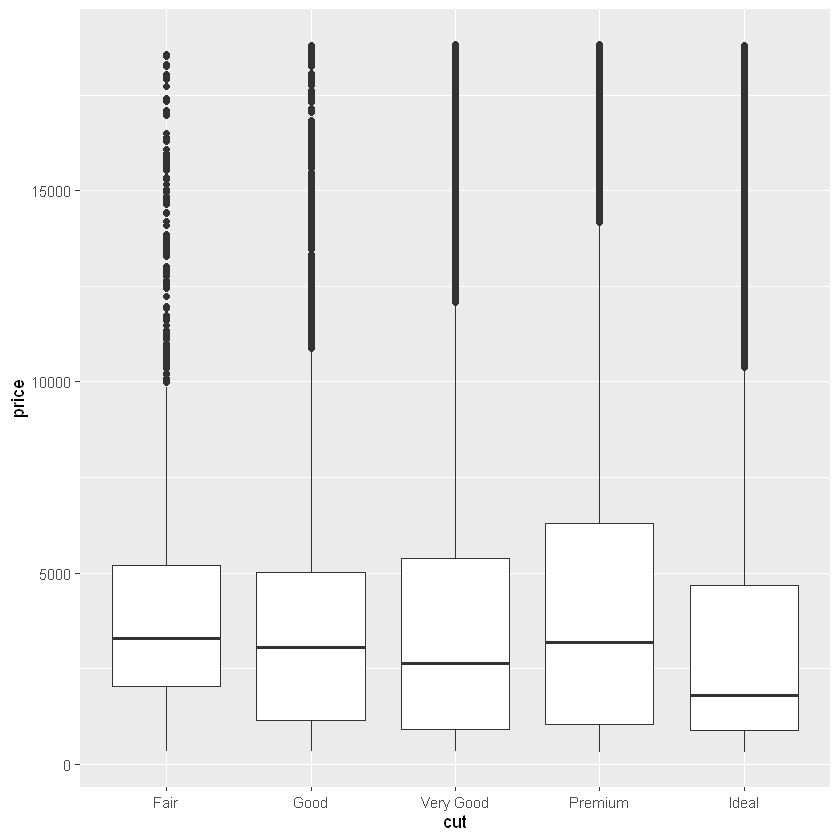

In [28]:
ggplot(data=diamonds, mapping=aes(x=cut, y=price)) +
    geom_boxplot()